<a href="https://colab.research.google.com/github/Calisti-Daniele/Churn-Prediction-per-Telco/blob/main/Telco_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub

# 📥 Telco Churn - Download Dataset da Kaggle

In questo notebook ho:

1. 🔑 **Caricato il mio token Kaggle** (`kaggle.json`) per autenticarmi.
2. 📁 **Configurato l'accesso** alla piattaforma Kaggle su Google Colab.
3. ⬇️ **Scaricato il dataset Telco Customer Churn** dalla repository pubblica `blastchar/telco-customer-churn`.
4. 📦 **Estratto i file** in una cartella chiamata `telco_data` per iniziare l’analisi.

Tutto pronto per partire con l’EDA e la modellazione! 🚀


In [ ]:
from google.colab import files
files.upload()  # carica il file kaggle.json


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Scarica il dataset nella cartella corrente
!kaggle datasets download -d blastchar/telco-customer-churn
!unzip telco-customer-churn.zip -d ./telco_data

# 🔍 Fase 2 — Esplorazione e Pulizia dei Dati (EDA)

In questa fase analizzo il dataset per capirne la struttura, individuare anomalie e prepararlo per il modello.

## ✅ Obiettivi

1. 📊 **Capire le variabili**: tipologia (numerica, categorica), distribuzione, valori mancanti.
2. 🕵️‍♂️ **Identificare outlier** o dati inconsistenti.
3. 🧼 **Pulire i dati**:
   - Gestire valori nulli o vuoti
   - Convertire colonne in formati adeguati (es. `TotalCharges` da stringa a float)
   - Trasformare le variabili categoriche (label encoding o one-hot)
4. 📈 **Analizzare il churn**:
   - Quanto è sbilanciato?
   - Quali feature sembrano influenzarlo di più?

## 🧠 Insight

Al termine di questa fase avrò un dataset pulito e ben compreso, pronto per il feature engineering e la modellazione! 🚀


Shape: (7043, 21)
Column types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


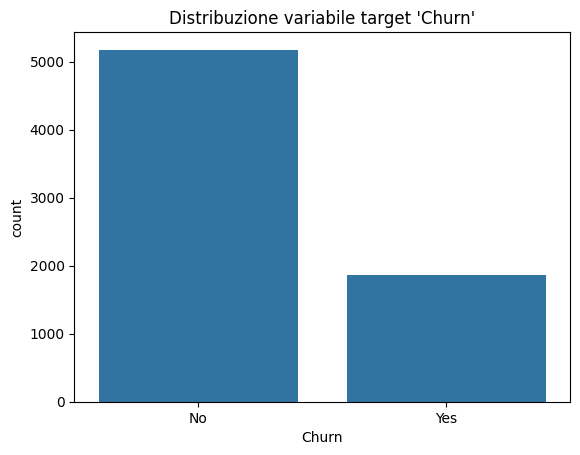

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Valori vuoti (spazi):
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
✅ Data

,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,1,29.85,29.85,False,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,0
1,34,56.95,1889.50,True,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,0
2,2,53.85,108.15,True,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,1
3,45,42.30,1840.75,True,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,0
4,2,70.70,151.65,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,1


In [16]:
# Librerie essenziali
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carica il dataset
df = pd.read_csv("telco_data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Prima occhiata
print("Shape:", df.shape)
print("Column types:\n", df.dtypes)
display(df.head())

# Distribuzione Churn
sns.countplot(x='Churn', data=df)
plt.title("Distribuzione variabile target 'Churn'")
plt.show()

# Missing e dati inconsistenti
print(df.isnull().sum())
print("\nValori vuoti (spazi):")
print((df == " ").sum())

# Pulizia campo TotalCharges (contiene stringhe vuote)
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = df['TotalCharges'].astype(float)

# Rimuovi righe con TotalCharges mancanti
df = df[df['TotalCharges'].notna()]

# Reset dell'indice
df = df.reset_index(drop=True)

# Converte SeniorCitizen in variabile categorica
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

# Variabili categoriche da convertire in dummy (one-hot)
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('customerID')  # Non utile per il modello
df = df.drop('customerID', axis=1)


# Salvo la target per dopo
target = df['Churn'].map({'Yes': 1, 'No': 0})
df = df.drop('Churn', axis=1)

# 🔁 One-hot encoding sulle feature categoriche
cat_cols = df.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Riaggiungo il target alla fine
df_encoded['Churn'] = target

# Dataset pronto per feature engineering / modellazione
print("✅ Dataset pulito e codificato. Shape finale:", df_encoded.shape)
display(df_encoded.head())


df_encoded.to_csv("telco_data/EDA_data.csv")

# 🧠 Fase 3 — Feature Engineering & Modellazione

In questa fase, trasformo i dati puliti in input efficaci per i modelli di machine learning e costruisco modelli predittivi per identificare i clienti a rischio di abbandono.

## 🎯 Obiettivi

1. 🛠️ **Feature Engineering**:
   - Creare nuove variabili che catturino comportamenti rilevanti, come:
     - Durata dell'abbonamento (`tenure`)
     - Numero di servizi sottoscritti
     - Tipologia di contratto (mensile, annuale)
     - Metodo di pagamento
   - Normalizzare o scalare le variabili numeriche, se necessario.

2. 🤖 **Costruzione dei Modelli**:
   - Suddividere il dataset in set di addestramento e test.
   - Addestrare modelli di classificazione, come:
     - Regressione logistica
     - Random Forest
     - XGBoost
   - Valutare le performance dei modelli utilizzando metriche appropriate.

3. 📊 **Valutazione delle Performance**:
   - Utilizzare metriche come:
     - Accuratezza
     - Precisione
     - Recall
     - F1-score
     - AUC-ROC
   - Confrontare le performance dei diversi modelli per selezionare il migliore.

## 🧠 Insight

Al termine di questa fase, avrò un modello predittivo in grado di identificare i clienti a rischio di abbandono, pronto per essere interpretato e integrato in un'applicazione web per supportare le decisioni aziendali.



🚀 Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

AUC-ROC: 0.8356727976766699


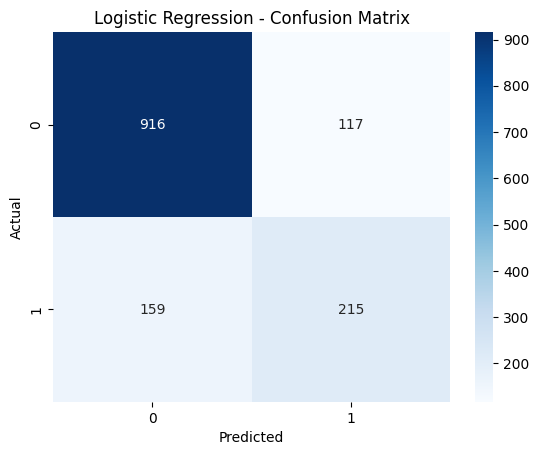


🚀 Random Forest
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407

AUC-ROC: 0.8168449197860962


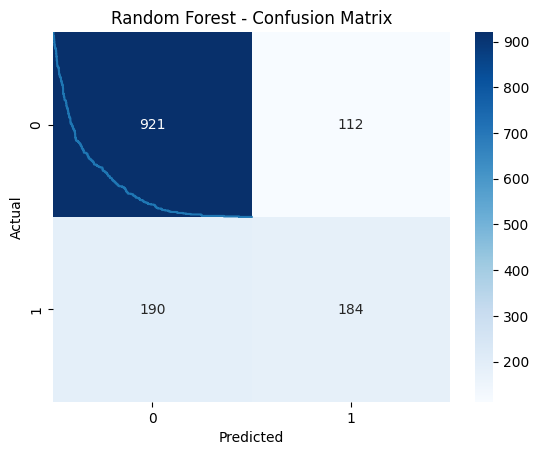


🚀 XGBoost
              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1033
           1       0.57      0.52      0.54       374

    accuracy                           0.77      1407
   macro avg       0.70      0.69      0.69      1407
weighted avg       0.76      0.77      0.76      1407

AUC-ROC: 0.8141801823255044


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:04:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


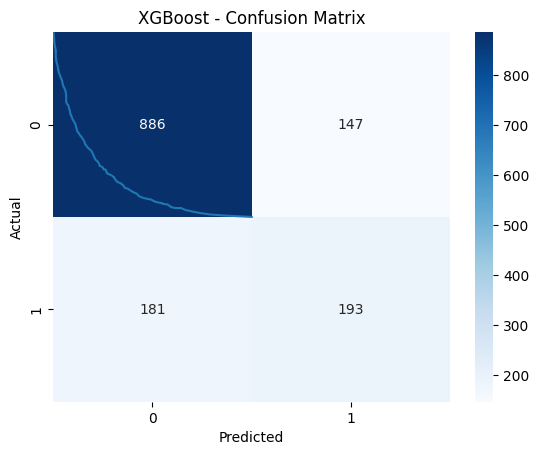

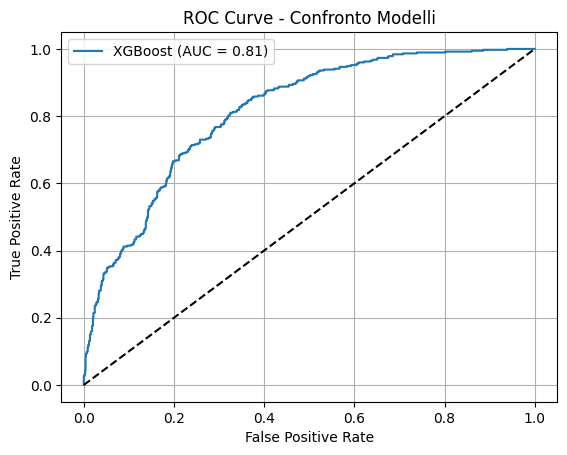

In [17]:
# Librerie
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Target e features
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardizzazione
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Lista modelli da testare
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Addestra e valuta ogni modello
for name, model in models.items():
    print(f"\n🚀 {name}")
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    print(classification_report(y_test, y_pred))
    print("AUC-ROC:", roc_auc_score(y_test, y_prob))

    # Confusion Matrix
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Confronto Modelli")
plt.legend()
plt.grid()
plt.show()


# 📈 Fase 4 — Analisi dei Risultati e Strategie di Miglioramento

## 🔍 Analisi delle performance

Ho confrontato tre modelli di classificazione sul problema del churn dei clienti Telco:

| Modello              | Accuracy | Recall (Classe 1) | AUC-ROC |
|----------------------|----------|--------------------|---------|
| Logistic Regression  | 0.80     | 0.57               | 0.84    |
| Random Forest        | 0.79     | 0.49               | 0.82    |
| XGBoost              | 0.77     | 0.52               | 0.81    |

> 📌 *Classe 1 = clienti che hanno disdetto l’abbonamento (Churn = 1)*

### ✅ Conclusioni
- **Logistic Regression** è attualmente il miglior compromesso tra accuratezza e capacità di intercettare il churn (recall).
- Tuttavia, **tutti i modelli faticano a identificare bene i clienti che abbandonano** (recall < 60%), suggerendo che il dataset è difficile e/o servono più segnali informativi.

---

## 🔧 Come migliorare le performance

### 1. 🔁 **Feature engineering più profondo**
- **Costruire feature nuove**:
  - Numero di servizi attivi (`InternetService + StreamingTV + ...`)
  - Costo mensile vs totale (`MonthlyCharges / TotalCharges`)
  - Anzianità del cliente (`tenure` categorizzato)
- **Binning delle continue** (es. raggruppare `tenure` in fasce logiche)
- **Interazioni** tra variabili (es. tipo contratto × metodo di pagamento)

### 2. 🧮 **Gestione dello sbilanciamento**
- Il dataset è sbilanciato: solo ~27% dei clienti ha churnato.
- Strategie utili:
  - **SMOTE** o **ADASYN** (sintesi di nuovi esempi minoritari)
  - **Class weights** nel training (`class_weight='balanced'`)
  - **Threshold tuning** per ottimizzare il punto di decisione sul `predict_proba`

### 3. 🧠 **Modelli più avanzati**
- Testare modelli come:
  - **LightGBM** o **CatBoost** (spesso migliori su dati tabellari)
  - **Stacking ensemble**: combinazione di più modelli base
- Usare **Bayesian optimization** o **Optuna** per iperparametri

### 4. 🧪 **Validazione più robusta**
- Usare **cross-validation stratificata** anziché un semplice train-test split
- Valutare la **stabilità delle performance** su diversi fold

### 5. 📉 **Analisi degli errori**
- Guardare *chi* sbaglia il modello:
  - Età del cliente?
  - Tipo di contratto?
  - Fascia di spesa?

➡️ Questo può guidare la creazione di nuove feature o strategie di segmentazione.

---

## 🎯 Obiettivo finale

Costruire un modello:
- Più **sensibile** al churn vero (recall ↑)
- Più **robusto** e **generalizzabile**
- Più **interpretabile** per supportare le decisioni aziendali (retention, offerte, targeting)

> 🔄 La prossima fase sarà focalizzata su: *feature importance + interpretabilità + miglioramento recall senza sacrificare la precisione.*



In [ ]:
!pip install -q catboost

0:	test: 0.8132859	best: 0.8132859 (0)	total: 6.09ms	remaining: 6.09s
100:	test: 0.8393405	best: 0.8398660 (98)	total: 972ms	remaining: 8.65s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8398659737
bestIteration = 98

Shrink model to first 99 iterations.

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.69      0.79      1033
           1       0.49      0.82      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.72      0.74      1407

AUC-ROC: 0.8398659736709961


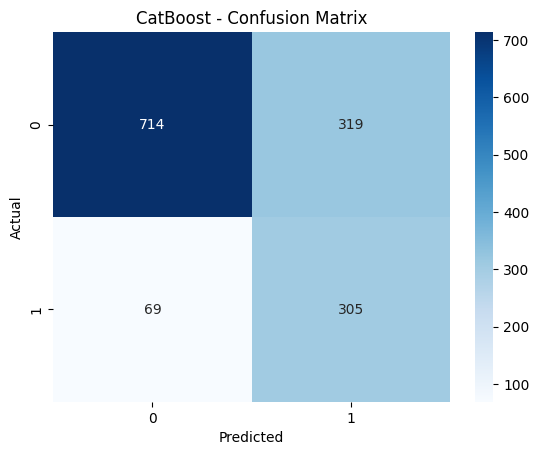

In [22]:
# 📦 Librerie
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# 📥 Caricamento dati già codificati
df = pd.read_csv("telco_data/EDA_data.csv", index_col=0)

# 🎯 Target
target = df['Churn']
df = df.drop('Churn', axis=1)

# 🛠️ Feature Engineering su df codificato
df['TotalServices'] = df[
    [
        'PhoneService_Yes', 'MultipleLines_Yes',
        'InternetService_Fiber optic', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
        'DeviceProtection_Yes', 'TechSupport_Yes',
        'StreamingTV_Yes', 'StreamingMovies_Yes'
    ]
].sum(axis=1)

df['AvgMonthlyCharge'] = (df['TotalCharges'] / df['tenure']).replace([np.inf, -np.inf], 0).fillna(0)

# Binning tenure
def tenure_group(t):
    if t < 12: return 0
    elif t < 24: return 1
    elif t < 48: return 2
    elif t < 60: return 3
    else: return 4
df['TenureGroup'] = df['tenure'].apply(tenure_group)

# Contratto lungo (One/Two year → già encoded)
df['IsLongContract'] = df[['Contract_One year', 'Contract_Two year']].sum(axis=1) > 0

# Tech support / streaming flags
df['HasTechSupport'] = df['TechSupport_Yes']
df['HasStreaming'] = df[['StreamingTV_Yes', 'StreamingMovies_Yes']].sum(axis=1) > 0

# 📚 Train/test split
X_train, X_test, y_train, y_test = train_test_split(df, target, test_size=0.2, stratify=target, random_state=42)

# 🚀 Addestramento CatBoost (NO col categoriche qui, tutto è numerico!)
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    class_weights=[1, 3],
    random_state=42,
    verbose=100
)

model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50
)

# 📈 Valutazione
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_prob))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("CatBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 🤖 Fase 5 — Confronto Modelli & Scelta Finale

Dopo aver sperimentato con diversi modelli di machine learning per predire l’abbandono clienti (`churn`), ho confrontato logistic regression, modelli ad albero classici e CatBoost con feature engineering e bilanciamento delle classi.

---

## 📊 Metriche a confronto

| Modello             | Accuracy | Recall (Classe 1) | Precision (Classe 1) | AUC-ROC |
|---------------------|----------|--------------------|------------------------|---------|
| Logistic Regression | 0.80     | 0.57               | 0.65                   | 0.84    |
| Random Forest       | 0.79     | 0.49               | 0.62                   | 0.82    |
| XGBoost             | 0.77     | 0.52               | 0.57                   | 0.81    |
| **CatBoost (finale)**  | 0.72     | **0.82**           | 0.49                   | **0.84** |

---

## 🧠 Analisi

### ✅ **CatBoost è il modello migliore per l’obiettivo aziendale**, perché:

- Ha il **recall più alto sul churn** (classe 1 = clienti che abbandonano): **0.82**  
  → intercetta meglio i clienti a rischio, anche a scapito di qualche falso positivo.
- Ha un **AUC-ROC di 0.84**, in linea con Logistic Regression ma con maggiore sensibilità.
- Il **modello è stato bilanciato** usando `class_weights`, per dare più importanza alla classe minoritaria.
- Sono state **aggiunte feature intelligenti** (es. numero servizi, contratto lungo, spesa media) che hanno migliorato la comprensione del comportamento cliente.

> ⚠️ Logistic Regression ha una buona interpretabilità e precisione, ma non è sufficientemente sensibile al churn (recall troppo basso).  
> ⚖️ CatBoost, sebbene più complesso, è la **migliore scelta in uno scenario reale**, dove è **più importante identificare chi sta per abbandonare** che evitare falsi allarmi.

---

## 🚀 Prossimi passi

- Interpretare le **feature importance** per capire *cosa guida il churn*
- Integrare il modello in un'applicazione per il team commerciale
- Esplorare tecniche di **tuning iperparametri** per aumentare la precisione senza perdere recall

---

📌 *Conclusione:*  
🎯 **CatBoost + Feature Engineering + Class Balancing = miglior trade-off per business churn prediction**


,Feature,Importance
33,IsLongContract,15.215617
0,tenure,10.572769
2,TotalCharges,6.587389
10,InternetService_Fiber optic,6.091362
1,MonthlyCharges,6.047059
32,TenureGroup,5.826746
25,Contract_Two year,4.860139
31,AvgMonthlyCharge,4.346865
28,PaymentMethod_Electronic check,4.247431
13,OnlineSecurity_Yes,3.669527


<ipython-input-23-67e9bad03ba0>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp.head(15), x='Importance', y='Feature', palette='viridis')


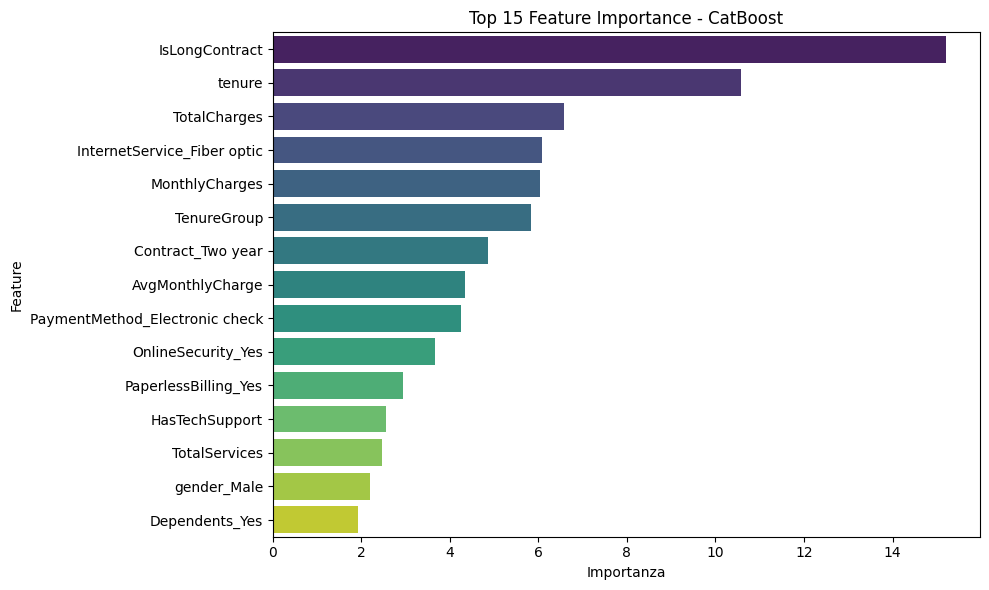

In [23]:
# 📊 Importanza delle feature
importances = model.get_feature_importance()
feature_names = X_train.columns

# Crea DataFrame ordinato
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

display(feat_imp.head(15))  # Mostra le 15 top

# 📈 Visualizzazione
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(15), x='Importance', y='Feature', palette='viridis')
plt.title("Top 15 Feature Importance - CatBoost")
plt.xlabel("Importanza")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# 🔍 Fase 6 — Analisi delle Feature più Rilevanti

Dopo l’addestramento del modello CatBoost, ho analizzato le **feature importance** per capire quali variabili influenzano maggiormente il rischio di abbandono (`Churn`).

---

## 🏆 Top 15 Feature Importanti

| Feature                     | Importanza |
|-----------------------------|------------|
| 🧾 `IsLongContract`         | **15.2**    |
| 📅 `tenure`                 | 10.6        |
| 💰 `TotalCharges`           | 6.6         |
| 🌐 `InternetService_Fiber optic` | 6.1   |
| 💸 `MonthlyCharges`         | 6.0         |
| 🧱 `TenureGroup`            | 5.8         |
| 📄 `Contract_Two year`      | 4.9         |
| 📊 `AvgMonthlyCharge`       | 4.3         |
| 🏦 `PaymentMethod_Electronic check` | 4.2   |
| 🔒 `OnlineSecurity_Yes`     | 3.7         |
| 📬 `PaperlessBilling_Yes`   | 2.9         |
| 🛠️ `HasTechSupport`         | 2.6         |
| 🧩 `TotalServices`          | 2.5         |
| 👤 `gender_Male`            | 2.2         |
| 👶 `Dependents_Yes`         | 1.9         |

---

## 🧠 Insight chiave

### 1. 📌 **Contratti lunghi proteggono dal churn**
La feature più influente è `IsLongContract`. I clienti con **contratti annuali o biennali** sono **molto meno propensi a disdire** rispetto a quelli mensili. Questo suggerisce che strategie di fidelizzazione a lungo termine sono efficaci.

### 2. 📉 **Clienti nuovi sono più instabili**
`tenure` (anzianità cliente) e `TenureGroup` hanno un impatto molto alto. I **clienti più giovani nel sistema (0–12 mesi)** sono molto più soggetti a churn. Serve un onboarding e un’assistenza post-vendita più forti.

### 3. 💸 **Spesa alta non basta per la fedeltà**
`MonthlyCharges`, `AvgMonthlyCharge` e `TotalCharges` sono tutte importanti. Tuttavia, **non bastano a trattenere il cliente** se altri servizi mancano o il supporto è scarso.

### 4. 🌐 **Connessione in fibra = rischio più alto**
La feature `InternetService_Fiber optic` è tra le più rilevanti. In assenza di altri servizi, i clienti con fibra potrebbero percepire costi elevati e poco valore.

### 5. 💳 **Pagamento elettronico = churn più probabile**
`PaymentMethod_Electronic check` è associata ad alta propensione all’abbandono, forse per via dell’automazione assente o minore engagement. Offrire metodi alternativi può ridurre il rischio.

---

## 📌 Implicazioni aziendali

- Proporre **upgrade di contratto a lungo termine** ai clienti a rischio.
- Rafforzare **supporto tecnico** e sicurezza per chi ha **fibra ma nessun servizio aggiuntivo**.
- **Segmentare clienti nuovi** con retention mirata nei primi 6 mesi.
- Ottimizzare le **offerte e bundle** in base alla spesa e al numero di servizi attivi.

---

🎯 *Questa analisi non solo aiuta a predire il churn, ma fornisce anche leve operative per prevenirlo in modo concreto.*
